# 第 1 讲：自行车为什么会倒——建模与开环运动

本讲不设计控制器。我们的目标是先建立一套足够简单、又能解释平衡问题的数学语言。

学习完成后，你应当能够：

1. 区分转向角、滚转角和滚转角速度；
2. 读懂 $\dot x=Ax+Bu$；
3. 用特征值判断系统会衰减还是发散；
4. 解释为什么这里使用的是简化模型，而 MuJoCo 使用的是完整多刚体模型。

## 1. 三个状态和一个控制输入

我们只保留平衡最关键的三个量：

- $\delta$：前轮转向角；
- $\phi$：车身滚转角，$\phi=0$ 表示竖直；
- $\dot\phi$：滚转角速度。

把它们排成一列，称为**状态向量**：

$$x=[\delta,\;\phi,\;\dot\phi]^T$$

控制输入是期望转向角速度 $u=\dot\delta$。注意：它还不是电机转矩。第 5 讲会再用一个电机内环把角速度指令变成转矩。

In [6]:
from dataclasses import dataclass
import math

import matplotlib.pyplot as plt
from matplotlib import font_manager
import numpy as np

np.set_printoptions(precision=4, suppress=True)
plt.style.use("seaborn-v0_8-bright")
available_fonts = {font.name for font in font_manager.fontManager.ttflist}
chinese_font = next((name for name in ["Arial Unicode MS", "PingFang HK", "Noto Sans CJK SC", "SimHei"] if name in available_fonts), "DejaVu Sans")
plt.rcParams.update({"font.sans-serif": [chinese_font], "axes.unicode_minus": False})


## 2. 小角度线性自行车模型

在滚转角较小、轮胎不侧滑、前进速度近似恒定时，项目中的模型可以写成：

$$\dot\delta=u$$
$$\dot\phi=\dot\phi$$
$$\ddot\phi=a_2\delta+a_4\phi+a_1u$$

其中

$$a_1=\frac{mahV\cos\lambda}{bI_b},\quad a_2=\frac{(mV^2h-macg)\cos\lambda}{bI_b},\quad a_4=\frac{mgh}{I_b}$$

$m$ 是质量，$h$ 是质心高度，$b$ 是轴距，$a$ 是后轮接地点到质心的水平距离，$c$ 是拖曳距，$\lambda$ 是转向轴倾角，$I_b$ 是绕地面纵轴的滚转转动惯量，$V$ 是前进速度。

最重要的观察是 $a_4>0$：车身向一侧倾斜后，重力不是把它拉回去，而是让它继续倒下。这就是倒立摆的特征。

In [7]:
@dataclass(frozen=True)
class BikeParameters:
    a: float = 0.117
    b: float = 0.271
    h: float = 0.292
    m: float = 5.0
    steering_axis_angle: float = 0.0
    trail: float = 0.0
    gravity: float = 9.81

    @property
    def roll_inertia(self):
        return 4.0 / 3.0 * self.m * self.h**2


def bicycle_matrices(speed, p=BikeParameters()):
    V = float(speed)
    cos_lam = math.cos(p.steering_axis_angle)
    Ib = p.roll_inertia
    a1 = p.m * p.a * p.h * V * cos_lam / (p.b * Ib)
    a2 = (p.m * V**2 * p.h - p.m * p.a * p.trail * p.gravity) * cos_lam / (p.b * Ib)
    a4 = p.m * p.gravity * p.h / Ib
    A = np.array([[0.0, 0.0, 0.0],
                  [0.0, 0.0, 1.0],
                  [a2,  a4,  0.0]])
    B = np.array([[1.0], [0.0], [a1]])
    return A, B


speed = 2.0
A, B = bicycle_matrices(speed)
print("A =\n", A)
print("B =\n", B)


A =
 [[ 0.      0.      0.    ]
 [ 0.      0.      1.    ]
 [37.9113 25.1969  0.    ]]
B =
 [[1.    ]
 [0.    ]
 [2.2178]]


## 3. 怎样读矩阵

矩阵方程 $\dot x=Ax+Bu$ 只是把前三条标量方程压缩到一起：

- `A` 第一行全为 0，`B` 第一行为 1，所以 $\dot\delta=u$；
- `A` 第二行是 `[0, 0, 1]`，所以状态的第三项就是滚转角的一阶导数；
- `A` 第三行描述转向角和滚转角怎样造成滚转加速度；
- `B` 第三项表示快速转向也会直接影响滚转加速度。

线性模型不是说真实自行车永远线性，而是说在竖直平衡点附近，可以用直线近似曲线。滚转达到几十度以后，这个近似就不应再被相信。

In [8]:
open_loop_poles = np.linalg.eigvals(A)
print("开环特征值：", open_loop_poles)
print("存在正实部吗？", bool(np.any(np.real(open_loop_poles) > 0)))


开环特征值： [ 5.0197 -5.0197  0.    ]
存在正实部吗？ True


一个模态如果按 $e^{\lambda t}$ 变化：

- $\lambda<0$：随时间衰减；
- $\lambda=0$：既不衰减也不增长；
- $\lambda>0$：指数增长。

因此，只要有一个特征值实部为正，开环系统就不稳定。下面从仅有 $0.5^\circ$ 初始倾斜开始，不施加任何控制。

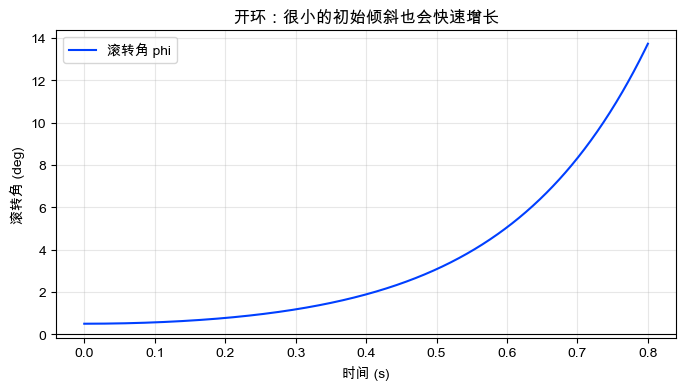

0.8 s 后滚转角：13.73 deg


In [9]:
def simulate_open_loop(A, B, x0, duration=0.8, dt=0.001):
    time = np.arange(0.0, duration + dt, dt)
    states = np.zeros((time.size, 3))
    states[0] = np.asarray(x0, dtype=float)
    for k in range(time.size - 1):
        # 足够小步长下的前向欧拉积分：x[k+1] = x[k] + x_dot * dt
        derivative = A @ states[k] + B[:, 0] * 0.0
        states[k + 1] = states[k] + derivative * dt
    return time, states


x0 = np.deg2rad([0.0, 0.5, 0.0])
time, states = simulate_open_loop(A, B, x0)

plt.figure(figsize=(8, 4))
plt.plot(time, np.rad2deg(states[:, 1]), label="滚转角 phi")
plt.axhline(0, color="black", linewidth=0.8)
plt.xlabel("时间 (s)")
plt.ylabel("滚转角 (deg)")
plt.title("开环：很小的初始倾斜也会快速增长")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()
print(f"0.8 s 后滚转角：{np.rad2deg(states[-1, 1]):.2f} deg")


## 4. 速度为什么重要

在这个简化模型里，直立且不转向时的重力发散项主要由 $a_4$ 决定；但一旦转动车把，$a_1$ 与 $a_2$ 都随速度变化。因此，同一个转向动作在不同速度下产生不同的滚转响应。控制增益也应随速度更新，这称为**增益调度**。

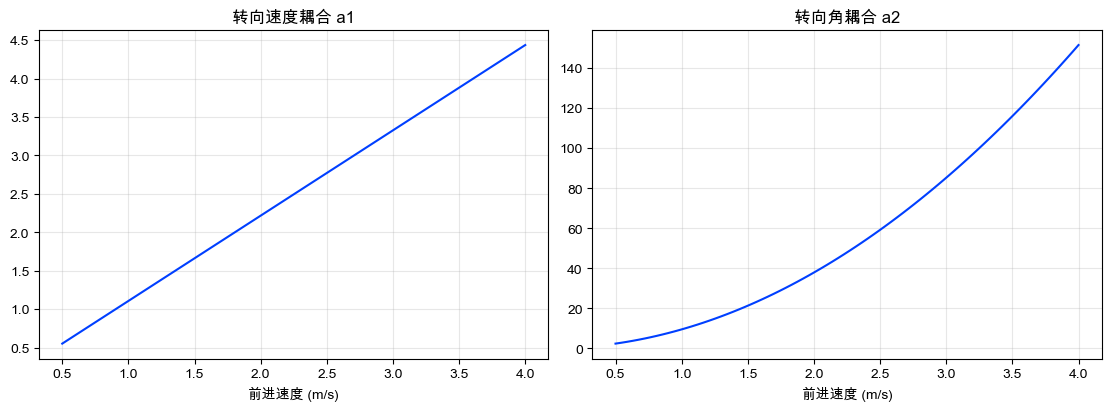

In [10]:
speeds = np.linspace(0.5, 4.0, 80)
a1_values, a2_values = [], []
for value in speeds:
    A_v, B_v = bicycle_matrices(value)
    a1_values.append(B_v[2, 0])
    a2_values.append(A_v[2, 0])

fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
axes[0].plot(speeds, a1_values)
axes[0].set_title("转向速度耦合 a1")
axes[1].plot(speeds, a2_values)
axes[1].set_title("转向角耦合 a2")
for axis in axes:
    axis.set_xlabel("前进速度 (m/s)")
    axis.grid(True, alpha=0.3)
plt.show()


## 5. 简化模型与 MuJoCo 模型不是同一个层级

本讲的三状态模型用于**设计控制器和形成直觉**。它忽略轮胎侧滑、横摆、接触冲击、执行器动态和车架三维惯量。MuJoCo XML 则包含浮动基座、前后轮、转向关节、接触摩擦、传感器和转矩执行器。

工程上常见的做法正是：用足够简单的模型设计控制器，再到更真实的仿真中检验。模型简单不等于没有价值，关键是清楚它在什么范围内可信。

## 练习

1. 把初始滚转角从 $0.5^\circ$ 改成 $1^\circ$，最终滚转角大约是否也变成两倍？这说明了线性系统的什么性质？
2. 找到开环滚转角首次超过 $10^\circ$ 的时间。
3. 修改质心高度 `h`，观察正特征值如何变化，并解释高质心为何更难平衡。
4. 思考：如果只有滚转角、没有滚转角速度传感器，控制器还缺少什么信息？